# Задача 5. Экспериментальное исследование алгоритмов для регулярных запросов

## Постановка задачи
Исследование посвящено анализу задачи достижимости в графе с учетом регулярного языка $L$. Необходимо определить множество $R' = \{(v_i, v_j) | w(v_i \pi v_j) \in L\}$, где $w(v_i \pi v_j)$ — последовательность меток на пути от вершины $v_i$ к $v_j$, принадлежащая языку $L$.

Основные вопросы исследования:

+ Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?
+ Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

Для достижения ответов на эти вопросы выполняются следующие этапы:

+ Анализ эффективности метода ```tensor_based_rpq```, решающего задачу для всех пар вершин, на различных представлениях матриц.

+ Оценка производительности метода ```ms_bfs_based_rpq```, который ограничивается заданным набором начальных вершин, на разных типах матриц.

+ Сравнение методов ```tensor_based_rpq``` и ```ms_bfs_based_rpq``` на графах с различными регулярными запросами и размерами стартового множества.

## Описание исследуемых решений

Первый алгоритм реализует обработку регулярных запросов через тензорное произведение. Он применяется для вычисления достижимости между всеми возможными парами вершин графа.

```python
def tensor_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    matrix_type: Type[spmatrix] = csr_matrix,
) -> set[tuple[int, int]]
```

Второй алгоритм представляет собой подход к регулярным запросам, основанный на методе msBFS с использованием линейной алгебры. Он предназначен для решения задачи достижимости, начиная с нескольких заданных стартовых вершин.

```python
def ms_bfs_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    matrix_type: spmatrix = csr_matrix,
) -> set[tuple[int, int]]
```

## Описание набора данных для экспериментов

### Графы

Графы выбирались из набора данных [CFPQ_Data](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html). 

Графы были выбраны по следующим типам:
1. Количество вершин больше, чем количество ребёр 
2. Количество рёбер больше, чем количество вершин
3. Количество вершин примерно равно количеству рёбер. Количество ребёр отличается менее, чем на 10% от количества вершин.

__так же были наложены ограничения на выбор графов - " < 50_000 вершин и  < 50_000 рёбер" из-за недостаточных вычислительных ресурсов для подсчёта настолько больших графов за приемлимое время.__

Примечание: к сожалению, после 5-ти часовой попытки обработать граф третьего типа так и не удалось по причине недостаточно мощного оборудования, поэтому обойдемся только двумя.

### Анализ репрезантативности выбранных графов

In [3]:
import sys

sys.path.append("../")
from utils import get_graph
import pandas as pd
from IPython.display import display
from collections import Counter
from collections import Counter
from functools import cache
import time
from typing import Callable, Type, List, Tuple

import matplotlib.pyplot as plt
import cfpq_data
from cfpq_data import generate_multiple_source_percent
from networkx import MultiDiGraph
from scipy.sparse import csr_matrix, csc_matrix, dok_matrix, lil_matrix, spmatrix
import numpy as np
import logging

from project.rpq import tensor_based_rpq, ms_bfs_based_rpq

import sources directory


In [ ]:
graphs = [
    "skos",
    "wc",
    "generations",
    "travel",
    "univ",
    "atom",
    "biomedical",
    "bzip",
    "foaf",
    "people",
    "pr",
    "funding",
    "ls",
    "wine",
    "pizza",
    "gzip",
    "core",
    "lusearch",
    "sunflow",
    "avrora",
    "eclipse",
]

graphs_data = [(graph, get_graph(graph)) for graph in graphs]

graphs_data_with_types = {}
for graph_data in graphs_data:
    graph_type = (
        3
        if graph_data[1].node_count * 0.95
        < graph_data[1].edge_count
        < graph_data[1].node_count * 1.05
        else 1
        if graph_data[1].node_count > graph_data[1].edge_count
        else 2
    )
    graphs_data_with_types.setdefault(graph_type, []).append(graph_data)

In [5]:
for type in [1, 2, 3]:
    df = pd.DataFrame(
        [
            (
                data[0],
                data[1].node_count,
                data[1].edge_count,
                len(data[1].edge_labels),
            )
            for data in graphs_data_with_types[type]
        ],
        columns=["graph", "node_count", "edge_count", "edge_labels"],
    ).style.set_caption(f"Graph type: {type}")

    display(df)

,graph,node_count,edge_count,edge_labels
0,wc,332,269,2
1,bzip,632,556,2
2,pr,815,692,2
3,ls,1687,1453,2
4,gzip,2687,2293,2


,graph,node_count,edge_count,edge_labels
0,skos,144,252,21
1,generations,129,273,17
2,travel,131,277,22
3,univ,179,293,14
4,atom,291,425,17
5,biomedical,341,459,10
6,foaf,256,631,15
7,people,337,640,25
8,funding,778,1086,20
9,wine,733,1839,35


,graph,node_count,edge_count,edge_labels
0,lusearch,15774,14994,680
1,sunflow,15464,15957,455
2,avrora,24690,25196,1568
3,eclipse,41383,40200,1477


Оставим по 2 графы из первых двух типов.

In [6]:
selected_graphs = {}
for type in [1, 2]:
    selected_graphs[type] = [graphs_data_with_types[type][0], graphs_data_with_types[type][-1]]

for type, data in selected_graphs.items():
    print(f"Graph type: {type}\nFirst graph: {data[0][0]}\nLast graph: {data[1][0]}")

Graph type: 1
First graph: wc
Last graph: gzip
Graph type: 2
First graph: skos
Last graph: core


### Запросы

Будем использовать наиболее часто встречающиеся метки для создания запросов.

Запросы будем генерировать по таким схемам, где где ```label_0```, ```label_1```, ```label_2```, ```label_3``` - самые часто встречающиеся метки. В случае двух меток ```label_0 = label_2```, ```label_1 = label_3```:

+ ```(label_0 | label_1) label_2*```
+ ```(label_0 label_2) (label_1 | label_3)*```
+ ```label_0+ label_3*```
+ ```(label_1 | label_2)+ (label_0 | label_1)*```



In [7]:
def get_most_common_labels_per_graph(selected_graphs):
    most_common_labels_per_graph = {}
    for type, graph_data in selected_graphs.items():
        # Extract the first and last graphs
        first_graph_name, first_graph = graph_data[0]
        last_graph_name, last_graph = graph_data[1]
        
        # Count the most common labels for the first graph
        counter_first = Counter(first_graph.edge_labels)
        most_common_labels_first = [label for label, _ in counter_first.most_common(4)]
        if len(most_common_labels_first) < 4:
            most_common_labels_first.extend([most_common_labels_first[0], most_common_labels_first[1]][:4 - len(most_common_labels_first)])
        
        # Count the most common labels for the last graph
        counter_last = Counter(last_graph.edge_labels)
        most_common_labels_last = [label for label, _ in counter_last.most_common(4)]
        if len(most_common_labels_last) < 4:
            most_common_labels_last.extend([most_common_labels_last[0], most_common_labels_last[1]][:4 - len(most_common_labels_last)])
        
        # Save the results
        most_common_labels_per_graph[type] = {
            'first_graph': (first_graph_name, most_common_labels_first),
            'last_graph': (last_graph_name, most_common_labels_last)
        }
    return most_common_labels_per_graph

def create_regular_expressions(most_common_labels_per_graph):
    regular_expressions = {}
    for type, graph_data in most_common_labels_per_graph.items():
        # Extract the first and last graph label data
        first_graph_name, labels_first = graph_data['first_graph']
        last_graph_name, labels_last = graph_data['last_graph']
        
        # Create regular expressions for the first graph
        label_1, label_2, label_3, label_4 = labels_first
        if len(set(labels_first)) == 2:
            label_3, label_4 = label_1, label_2
        regex1_first = f"({label_1} | {label_2}) {label_3}*"
        regex2_first = f"({label_1} {label_3}) ({label_2} | {label_4})*"
        regex3_first = f"{label_1}+ {label_4}*"
        regex4_first = f"({label_2} | {label_3})+ ({label_1} | {label_2})*"
        
        # Create regular expressions for the last graph
        label_1, label_2, label_3, label_4 = labels_last
        if len(set(labels_last)) == 2:
            label_3, label_4 = label_1, label_2
        regex1_last = f"({label_1} | {label_2}) {label_3}*"
        regex2_last = f"({label_1} {label_3}) ({label_2} | {label_4})*"
        regex3_last = f"{label_1}+ {label_4}*"
        regex4_last = f"({label_2} | {label_3})+ ({label_1} | {label_2})*"
        
        # Save the regular expressions for both graphs
        regular_expressions[type] = {
            'first_graph': (first_graph_name, [regex1_first, regex2_first, regex3_first, regex4_first]),
            'last_graph': (last_graph_name, [regex1_last, regex2_last, regex3_last, regex4_last])
        }
    return regular_expressions

# Example usage
selected_graphs = {}
for type in [1, 2]:
    selected_graphs[type] = [
        (graphs_data_with_types[type][0][0], graphs_data_with_types[type][0][1]),  # First graph
        (graphs_data_with_types[type][-1][0], graphs_data_with_types[type][-1][1])  # Last graph
    ]

most_common_labels_per_graph = get_most_common_labels_per_graph(selected_graphs)
regular_expressions = create_regular_expressions(most_common_labels_per_graph)

# Collect the results
results = []
for type, graph_data in regular_expressions.items():
    first_graph_name, regex_list_first = graph_data['first_graph']
    last_graph_name, regex_list_last = graph_data['last_graph']
    results.append([type, first_graph_name] + regex_list_first)
    results.append([type, last_graph_name] + regex_list_last)

# Create a DataFrame
df = pd.DataFrame(
    results,
    columns=["Type", "Graph", "Regex 1", "Regex 2", "Regex 3", "Regex 4"]
)

# Display the DataFrame
display(df)


,Type,Graph,Regex 1,Regex 2,Regex 3,Regex 4
0,1,wc,(a | d) a*,(a a) (d | d)*,a+ d*,(d | a)+ (a | d)*
1,1,gzip,(a | d) a*,(a a) (d | d)*,a+ d*,(d | a)+ (a | d)*
2,2,skos,(scopeNote | isDefinedBy) comment*,(scopeNote comment) (isDefinedBy | inverseOf)*,scopeNote+ inverseOf*,(isDefinedBy | comment)+ (scopeNote | isDefine...
3,2,core,(isDefinedBy | onClass) comment*,(isDefinedBy comment) (onClass | inverseOf)*,isDefinedBy+ inverseOf*,(onClass | comment)+ (isDefinedBy | onClass)*


Выше в таблице продемонстрированы запросы для каждого конкретного графа, которые мы будем использовать.

## Описание эксперимента 

### Оборудование

Эксперимент проводился c процессором 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, 16GB RAM (3200 МГц) и ОС Ubuntu 22.

### Ход эксперимента

В рамках эксперимента были поставлены две ключевые задачи:

1. **Анализ эффективности представления разреженных матриц.**  
   Для ответа на этот вопрос были выбраны наиболее часто используемые форматы разреженных матриц из библиотеки `scipy.sparse`:  
   - [`csr_matrix`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.html)  
   - [`csc_matrix`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csc_matrix.html)  
   - [`dok_matrix`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_matrix.html)  
   - [`lil_matrix`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html)  

   Оба алгоритма запускались на каждом графе и регулярном выражении. Для каждого типа матриц проводилось 20 запусков, по результатам которых вычислялось среднее время работы и стандартное отклонение. Ожидается, что форматы ```csr``` и ```csc```, оптимизированные для операций над разреженными данными, покажут лучшие результаты по сравнению с ```dok``` и ```lil```, особенно на больших графах.

2. **Определение порогового размера стартового множества.**  
   Для исследования этого вопроса алгоритмы тестировались с разными размерами множества стартовых вершин. Для каждого регулярного выражения измерялось время выполнения в зависимости от количества стартовых вершин. Каждый эксперимент повторялся 20 раз для получения средних значений и стандартных отклонений. Гипотеза заключается в том, что пороговый размер стартового множества зависит как от размера графа, так и от сложности регулярных выражений.

## Эксперимент

In [62]:
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

sparse_matrix_types = [csr_matrix, csc_matrix, dok_matrix, lil_matrix]
samples_count = 10
patterns = [
    "({label0} | {label1}) {label2}*",
    "({label0} {label2}) ({label1} | {label3})*",
    "{label0}+ {label3}*",
    "({label1} | {label2})+ ({label0} | {label1})*",
]
top_label_count = 4
random_seed = 42
GraphIdentifier = str

def replace_placeholders_with_labels(pattern: str, labels: List[str]) -> str:
    if len(labels) == 2:
        labels = [labels[0], labels[1], labels[0], labels[1]]

    substitutions = {}
    for idx, label in enumerate(labels[:top_label_count]):
        if f"label{idx}" in pattern:
            substitutions[f"label{idx}"] = label
    return pattern.format(**substitutions)

def extract_top_labels(graph: MultiDiGraph) -> List[str]:
    _, _, edge_labels = zip(*graph.edges(data="label"))
    top_labels, _ = zip(*Counter(edge_labels).most_common(top_label_count))
    return top_labels

def load_graph_by_name(name: GraphIdentifier) -> MultiDiGraph:
    graph_path = cfpq_data.download(name)
    return cfpq_data.graph_from_csv(graph_path)

@cache
def analyze_regex_performance(graph_id: GraphIdentifier, start_state_ratio: float):
    graph = load_graph_by_name(graph_id)
    performance_data = []

    def measure_execution_time(graph: MultiDiGraph, regex: str, matrix_cls: Type[spmatrix]) -> Tuple[Tuple[float, float], Tuple[float, float]]:
        settings = {
            "regex": regex,
            "graph": graph,
            "start_nodes": generate_multiple_source_percent(graph=graph, percent=start_state_ratio, seed=random_seed),
            "final_nodes": None,
            "matrix_type": matrix_cls,
        }

        def timed_execution(rpq_method: Callable) -> float:
            start_time = time.time()
            _ = rpq_method(**settings)
            end_time = time.time()
            return end_time - start_time

        tensor_timings = np.array([timed_execution(tensor_based_rpq) for _ in range(samples_count)])
        bfs_timings = np.array([timed_execution(ms_bfs_based_rpq) for _ in range(samples_count)])

        def exclude_outliers(data: np.ndarray, threshold: float = 2.0) -> np.ndarray:
            deviation = np.abs(data - np.median(data))
            median_deviation = np.median(deviation)
            scaled_deviation = deviation / median_deviation if median_deviation else np.zeros(len(deviation))
            return data[scaled_deviation < threshold]

        ms_per_second = 1000
        tensor_timings = exclude_outliers(tensor_timings * ms_per_second)
        bfs_timings = exclude_outliers(bfs_timings * ms_per_second)

        return (
            (np.median(tensor_timings), np.std(tensor_timings)),
            (np.median(bfs_timings), np.std(bfs_timings)),
        )

    most_common_labels = extract_top_labels(graph)
    for pattern in map(
        lambda pat: replace_placeholders_with_labels(pat, most_common_labels), patterns
    ):
        regex_results = [
            measure_execution_time(graph, pattern, matrix_cls) for matrix_cls in sparse_matrix_types
        ]
        performance_data.append(regex_results)

    return performance_data

def visualize_results(graph_id: str, start_state_ratio: float):
    performance_data = analyze_regex_performance(graph_id, start_state_ratio)
    matrix_type_data = zip(*performance_data)

    fig, ax = plt.subplots()
    x_positions = np.arange(len(patterns))
    bar_width = 0.1

    for idx, matrix_results in enumerate(matrix_type_data):
        tensor_metrics, bfs_metrics = zip(*matrix_results)
        tensor_means, tensor_stds = zip(*tensor_metrics)
        bfs_means, bfs_stds = zip(*bfs_metrics)
        matrix_name = sparse_matrix_types[idx].__name__

        ax.bar(
            x_positions + 2 * idx * bar_width,
            tensor_means,
            yerr=tensor_stds,
            width=bar_width,
            label=f"Tensor-based ({matrix_name})",
            color="violet",
        )
        ax.bar(
            x_positions + (2 * idx + 1) * bar_width,
            bfs_means,
            yerr=bfs_stds,
            width=bar_width,
            label=f"MS BFS-based ({matrix_name})",
            color="red",
        )

    fig.set_size_inches(15, 10)
    ax.set_xlabel("Regex Patterns")
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"Performance for {graph_id} (Start State Ratio: {start_state_ratio})")
    ax.set_xticks(x_positions + bar_width * len(sparse_matrix_types))
    ax.set_xticklabels(patterns, rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()


/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


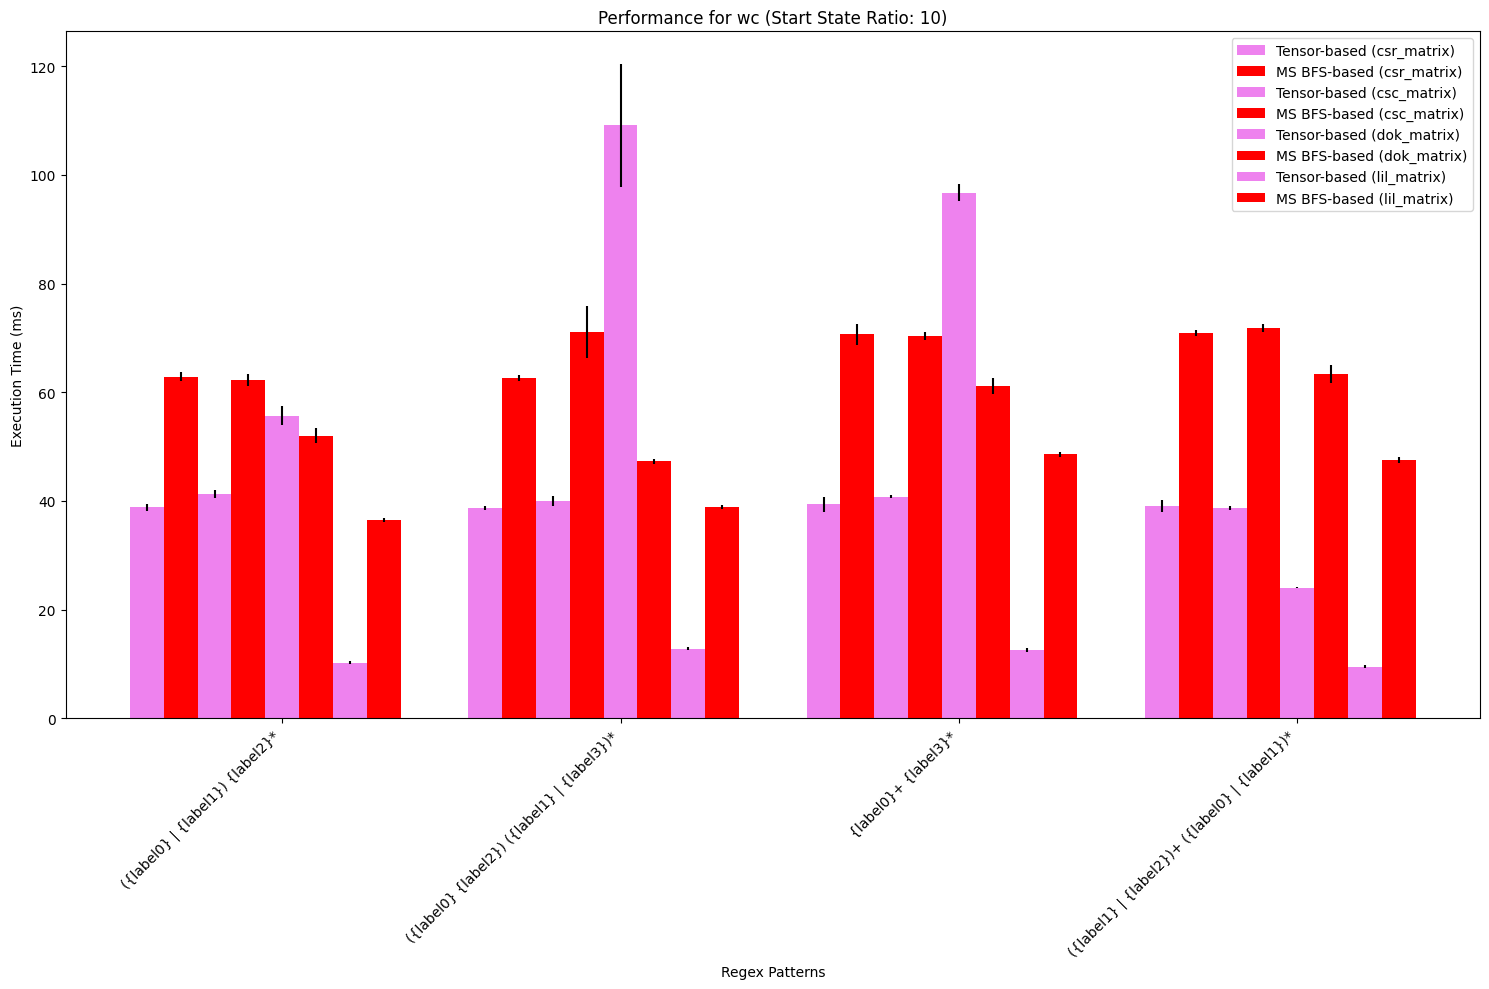

In [63]:
visualize_results("wc", 10)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


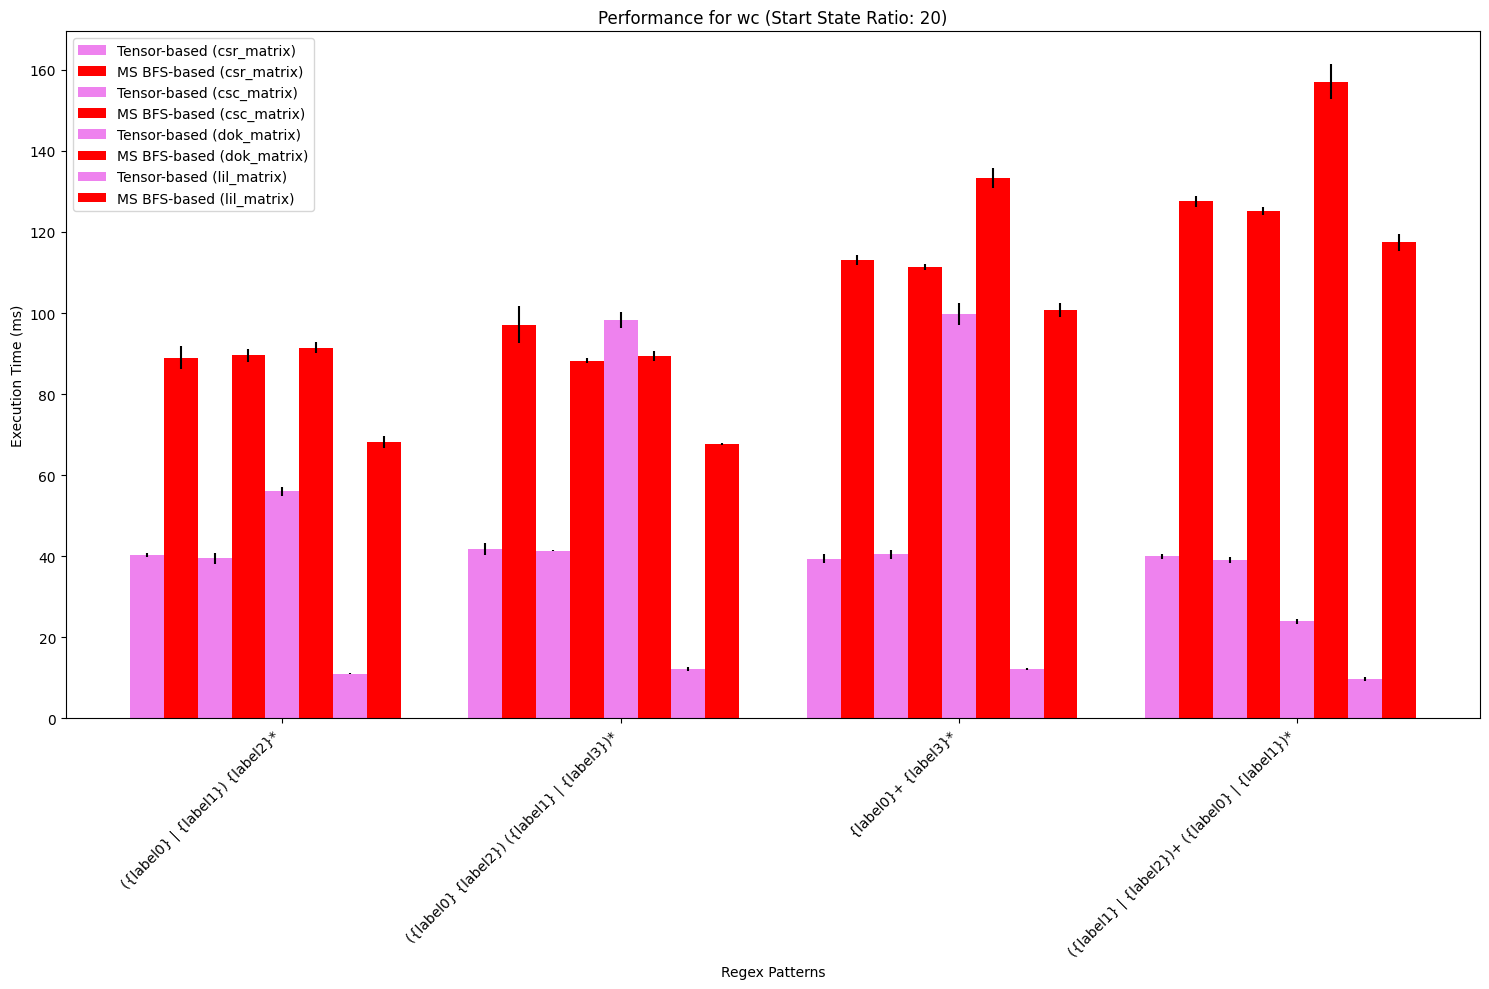

In [64]:
visualize_results("wc", 20)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


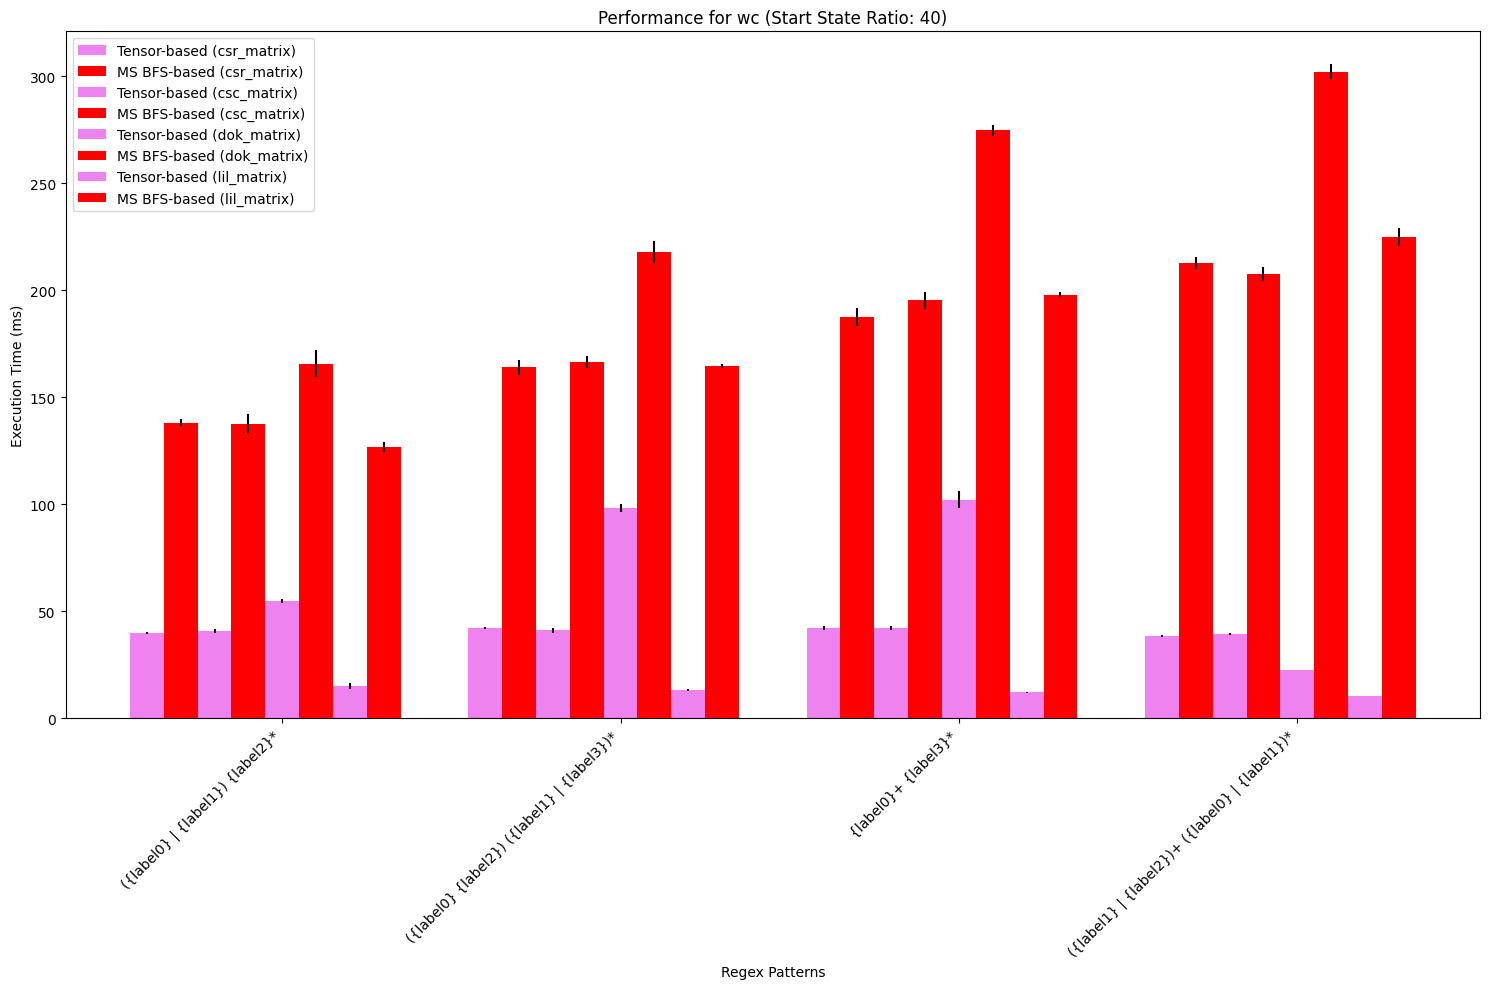

In [65]:
visualize_results("wc", 40)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


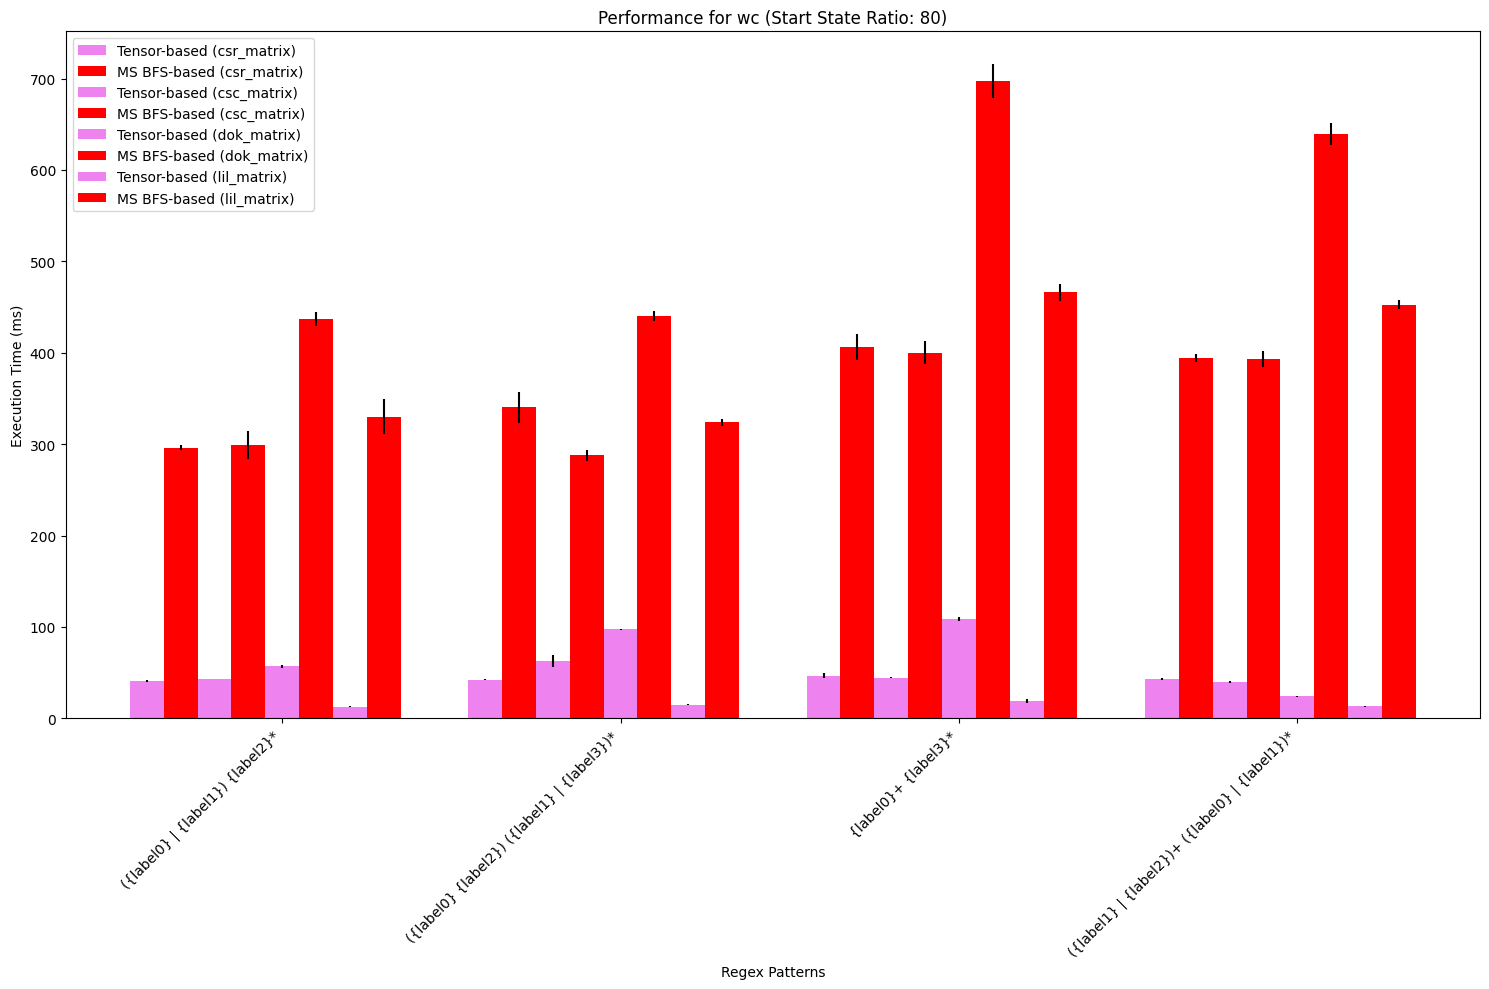

In [66]:
visualize_results("wc", 80)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


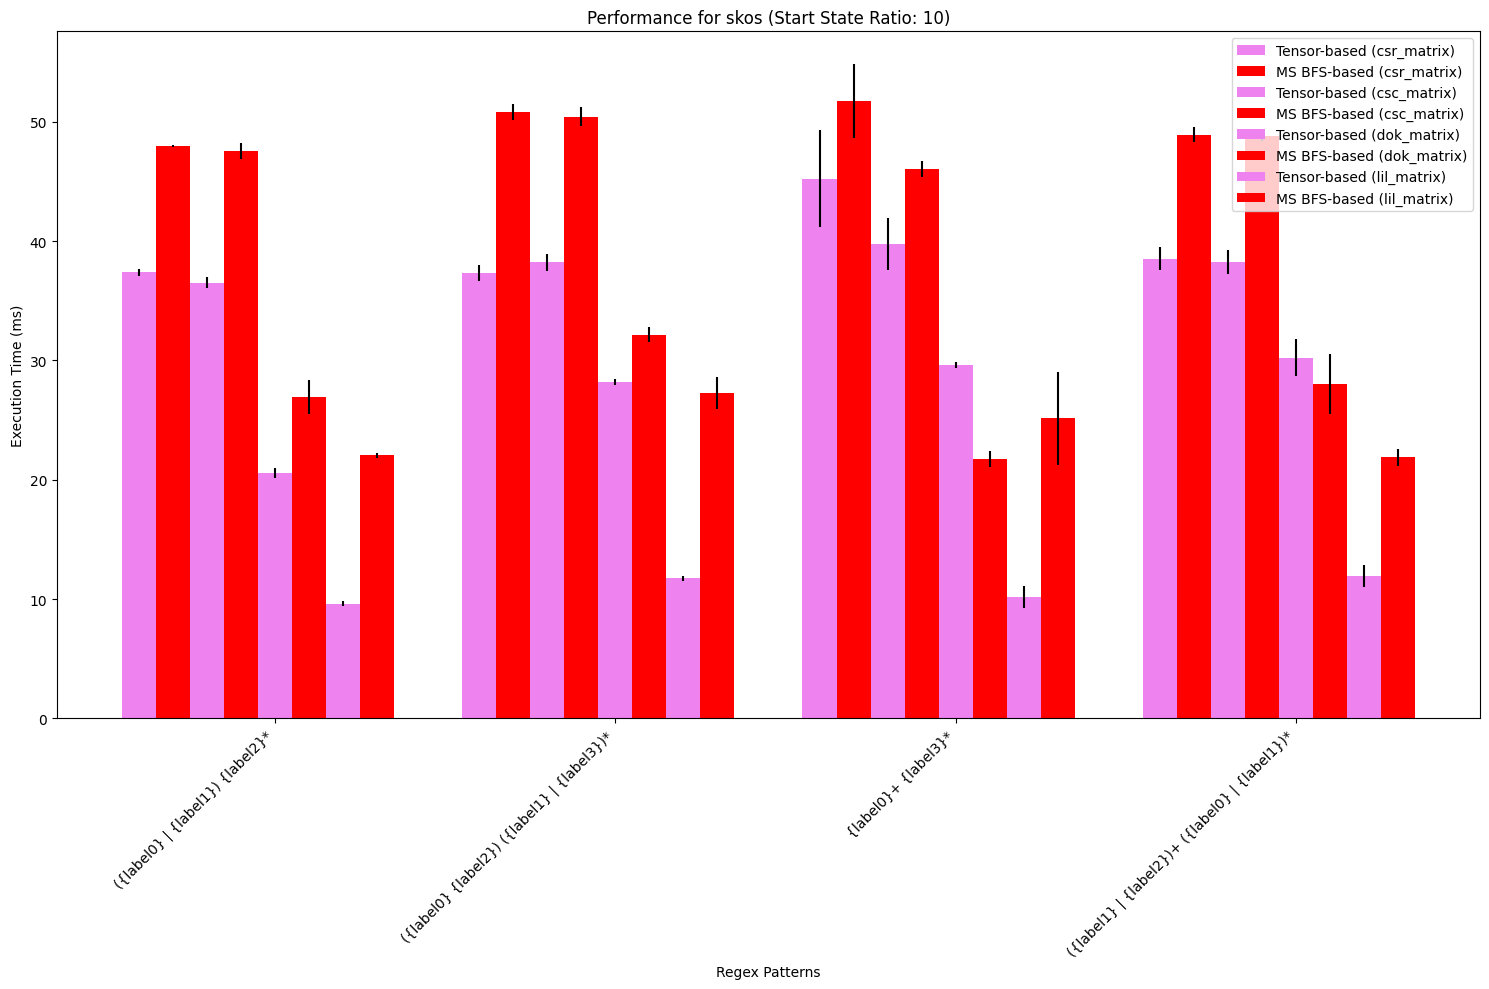

In [67]:
visualize_results("skos", 10)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


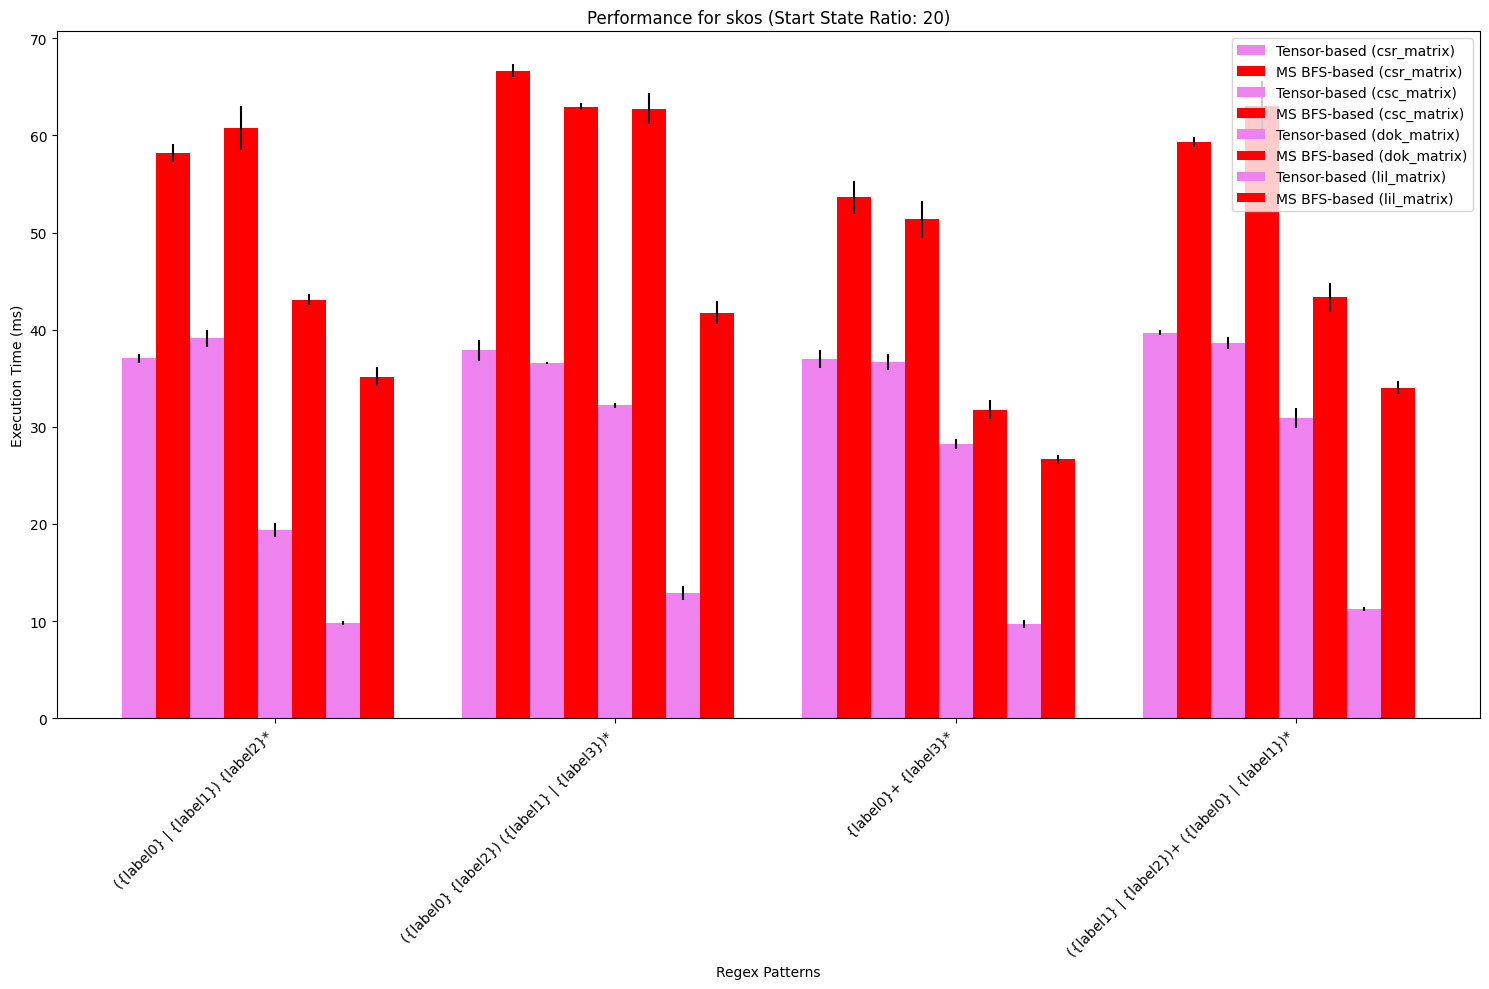

In [68]:
visualize_results("skos", 20)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


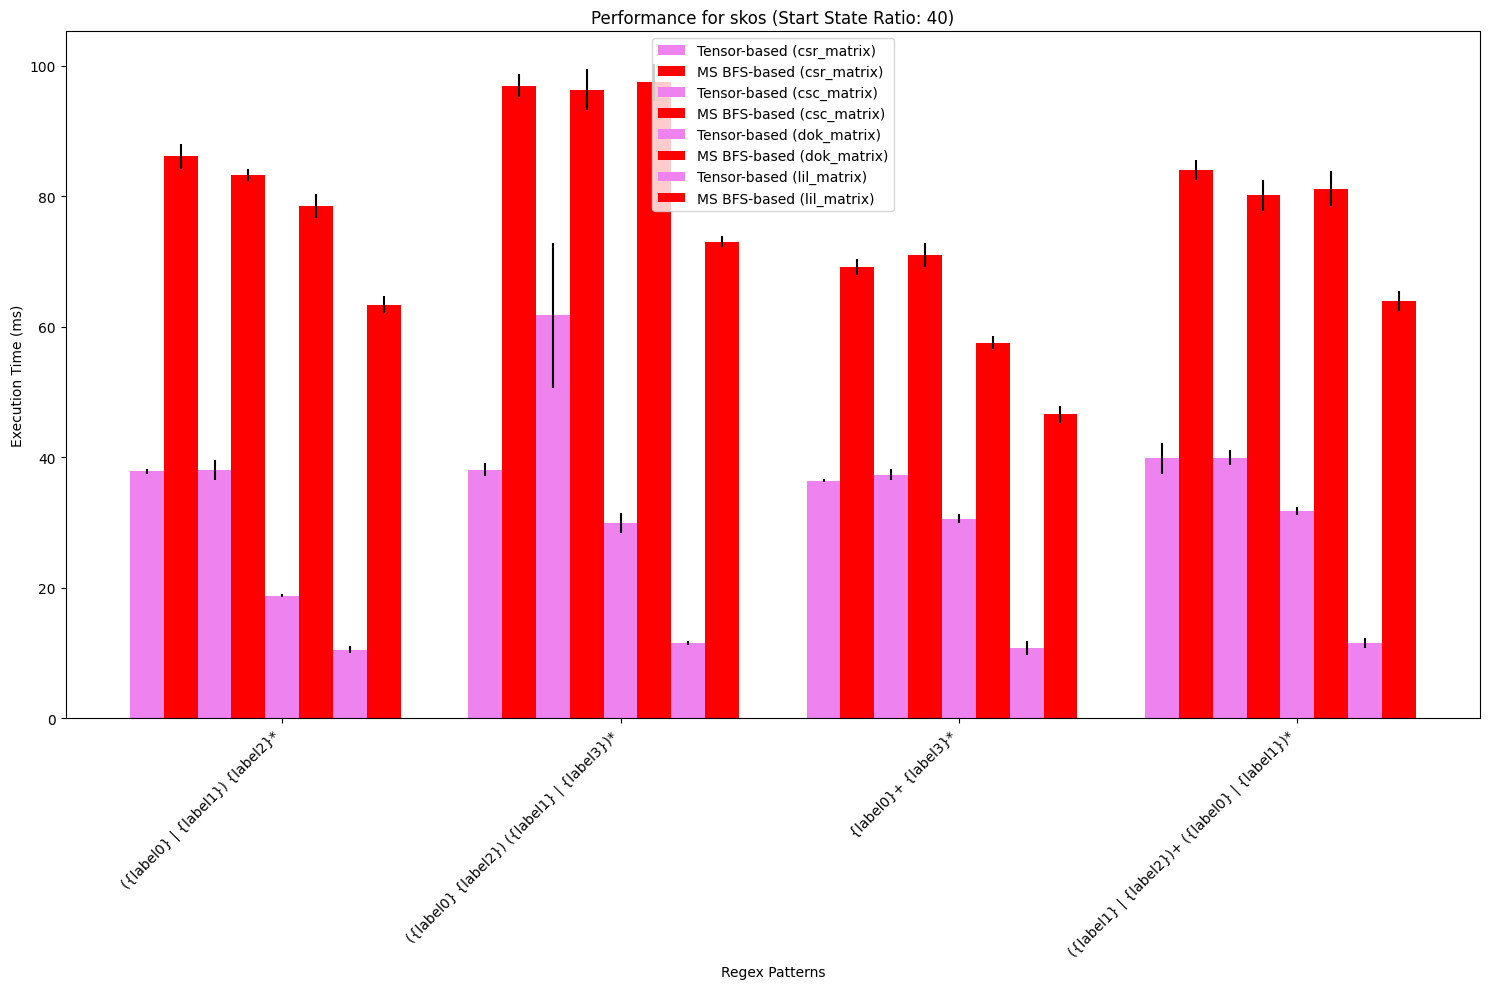

In [69]:
visualize_results("skos", 40)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


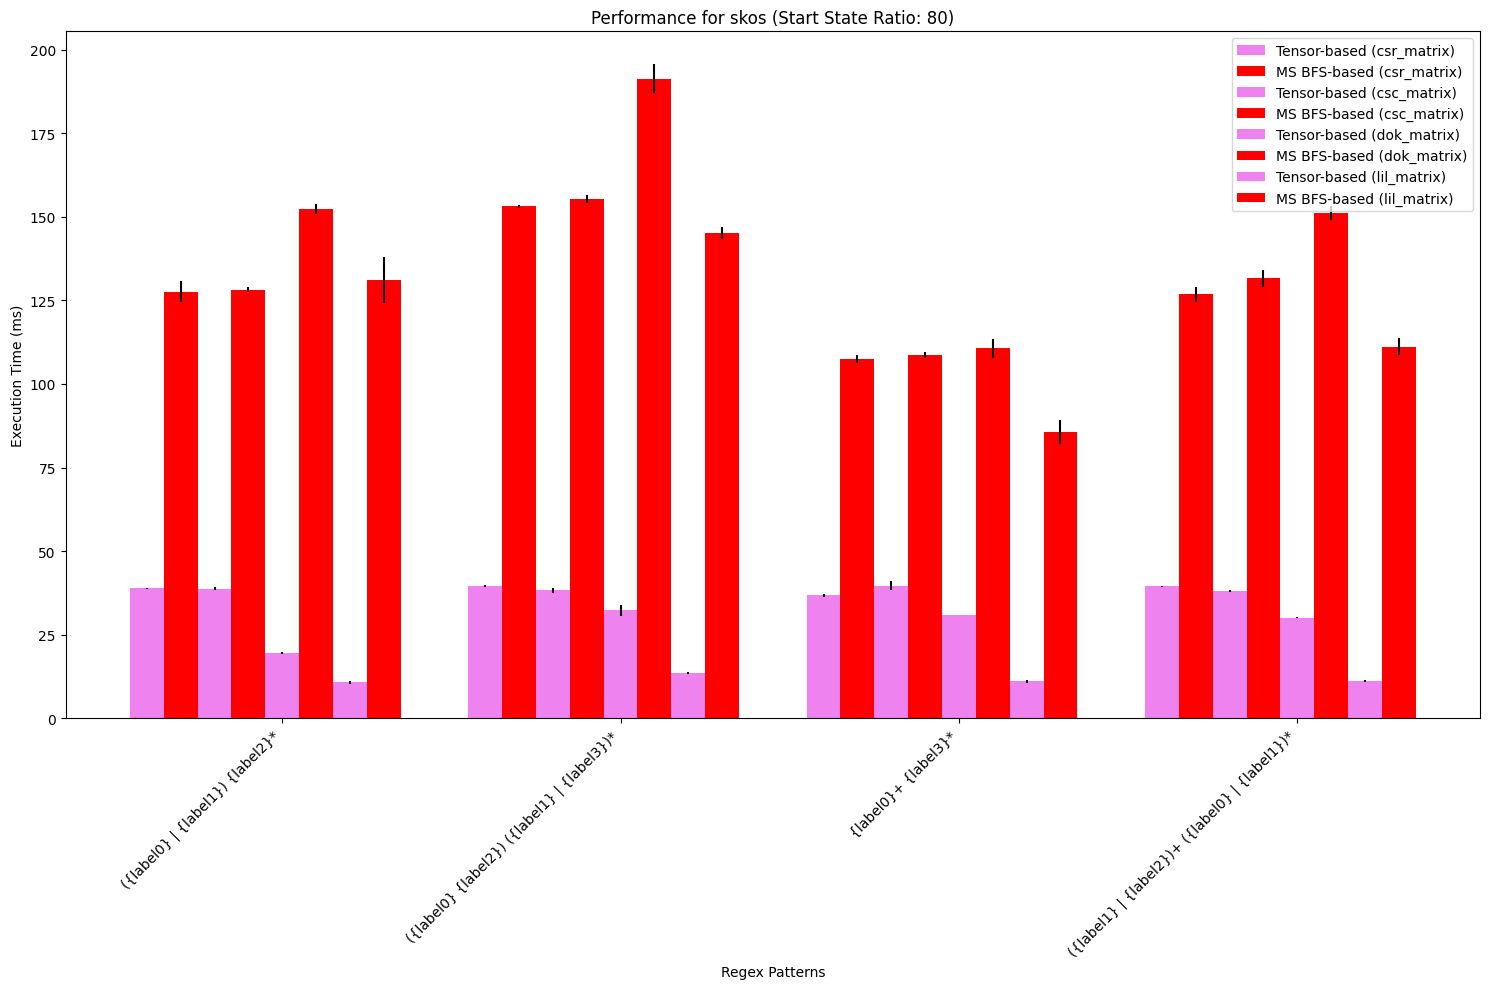

In [70]:
visualize_results("skos", 80)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


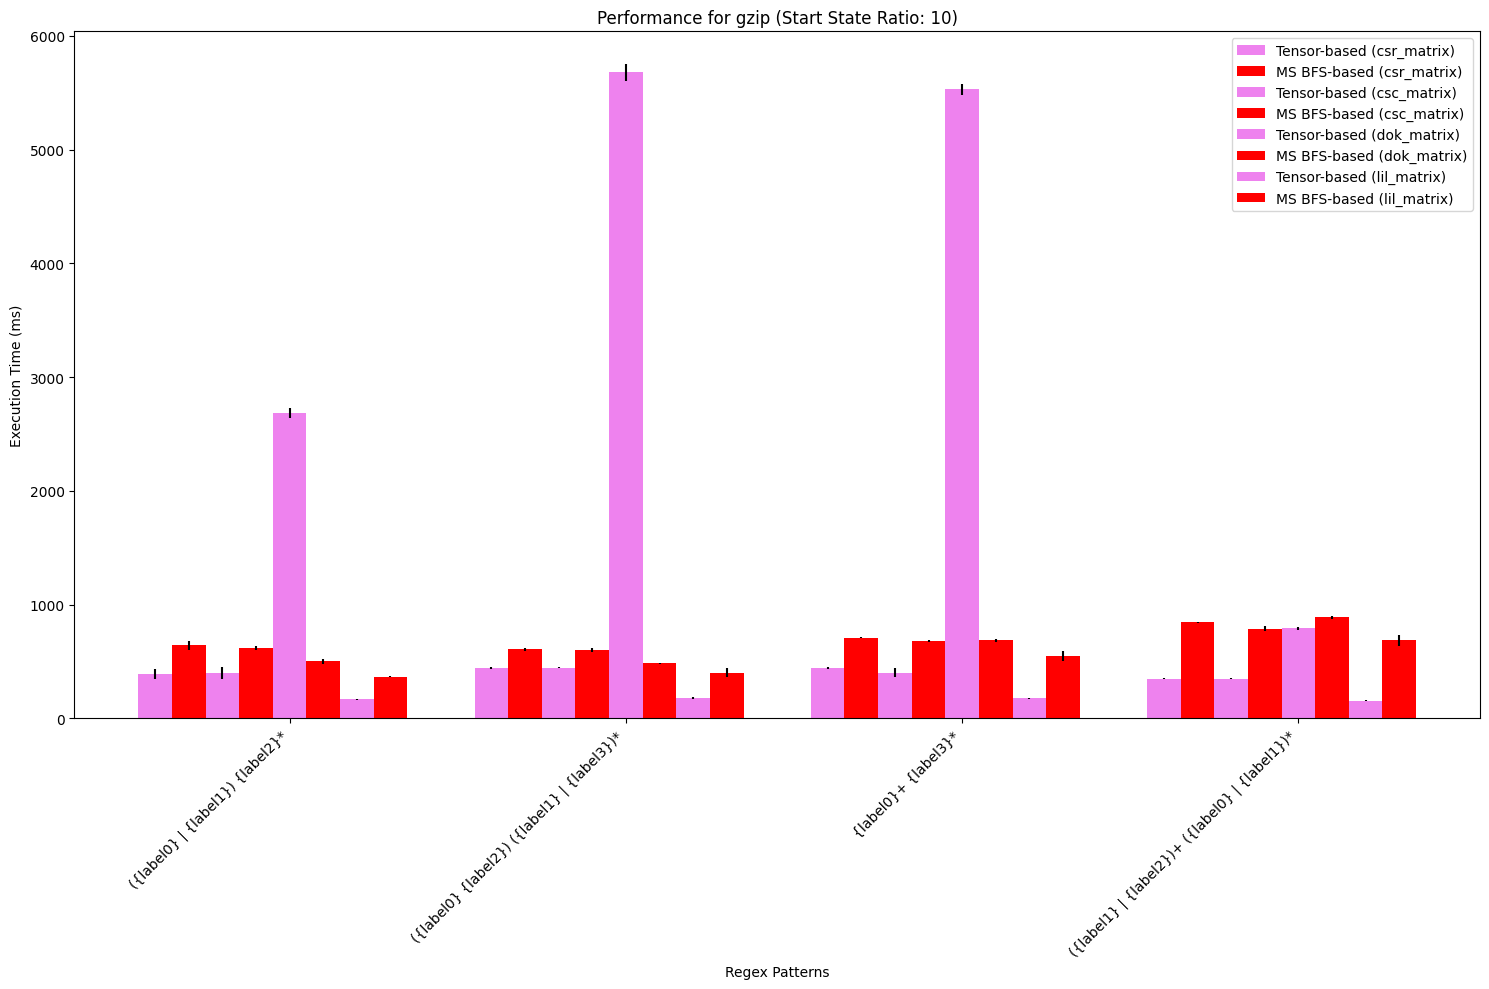

In [71]:
visualize_results("gzip", 10)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


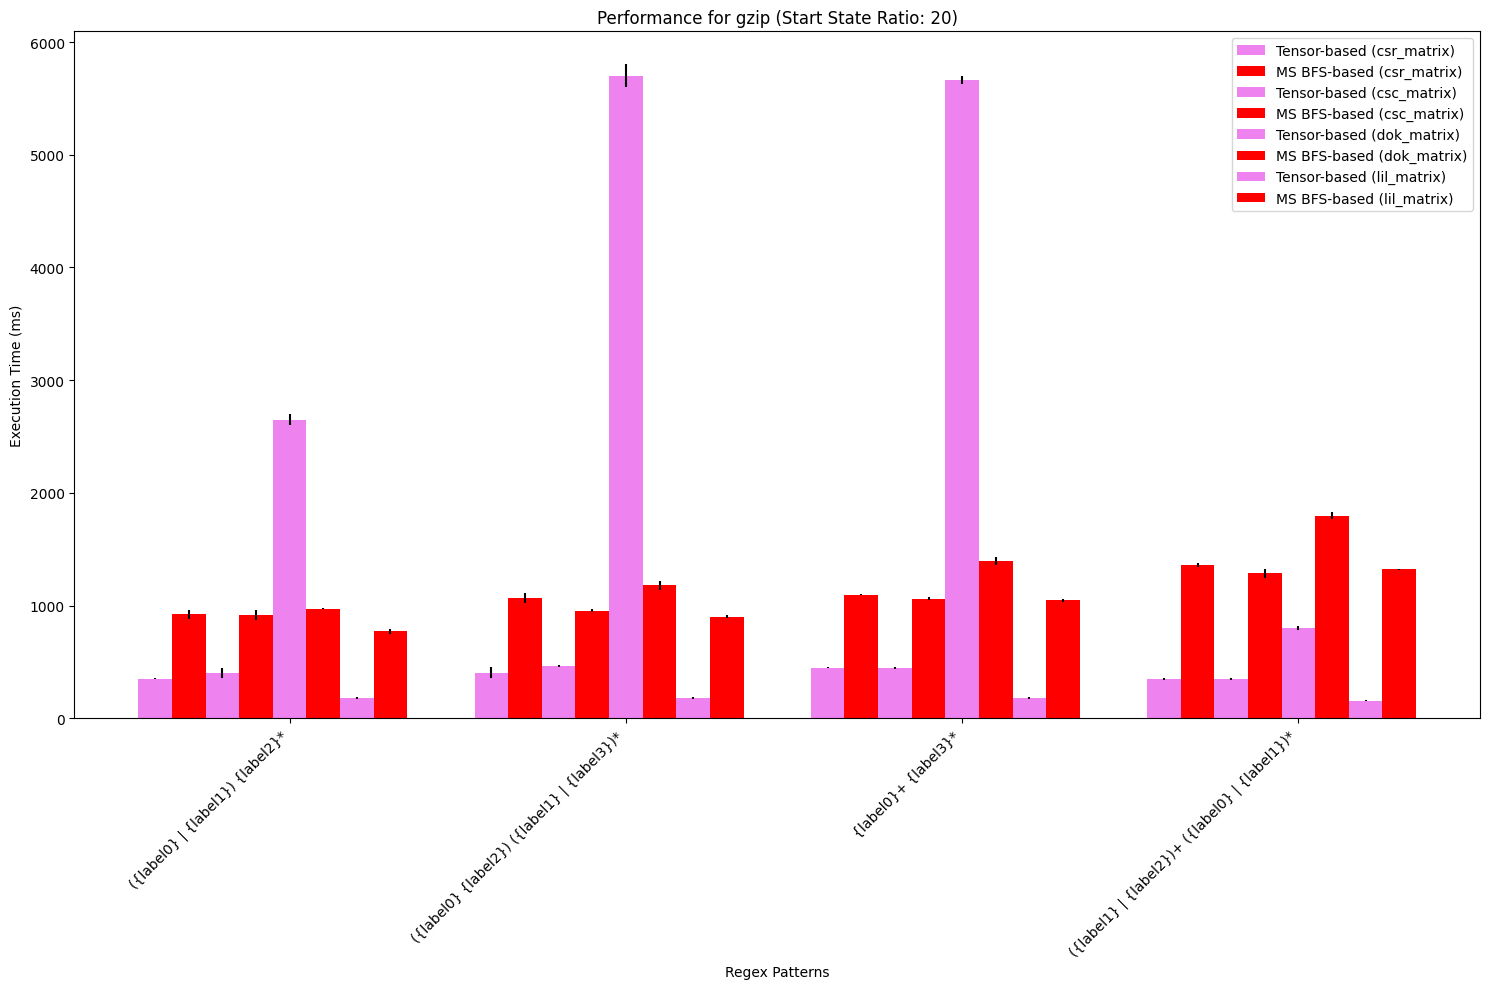

In [72]:
visualize_results("gzip", 20)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


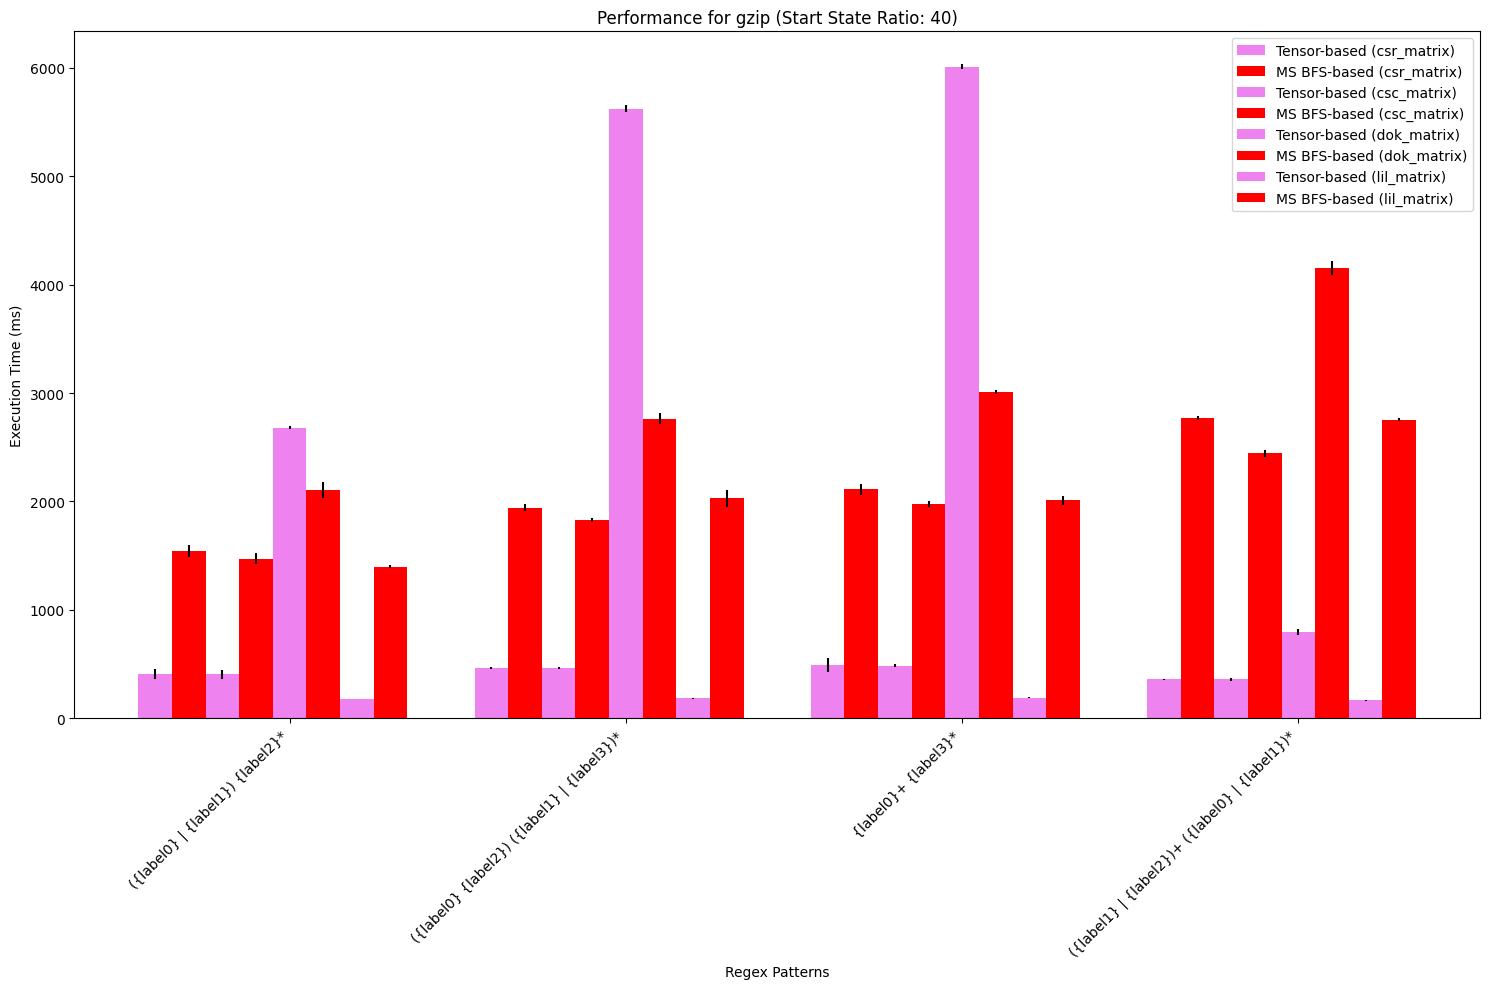

In [73]:
visualize_results("gzip", 40)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


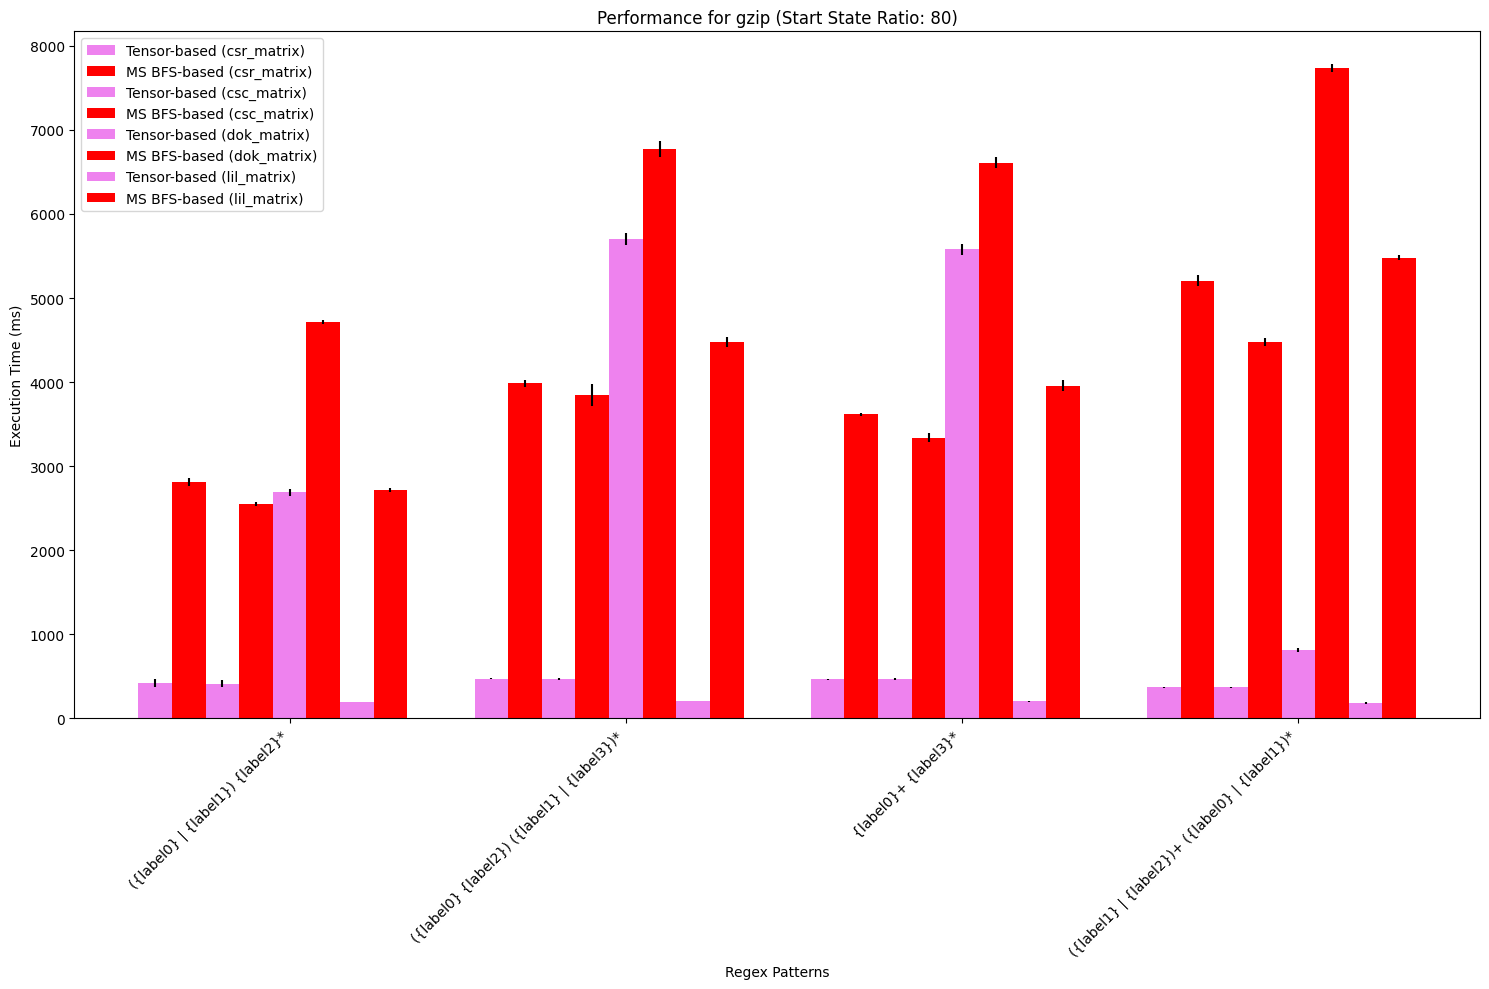

In [74]:
visualize_results("gzip", 80)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


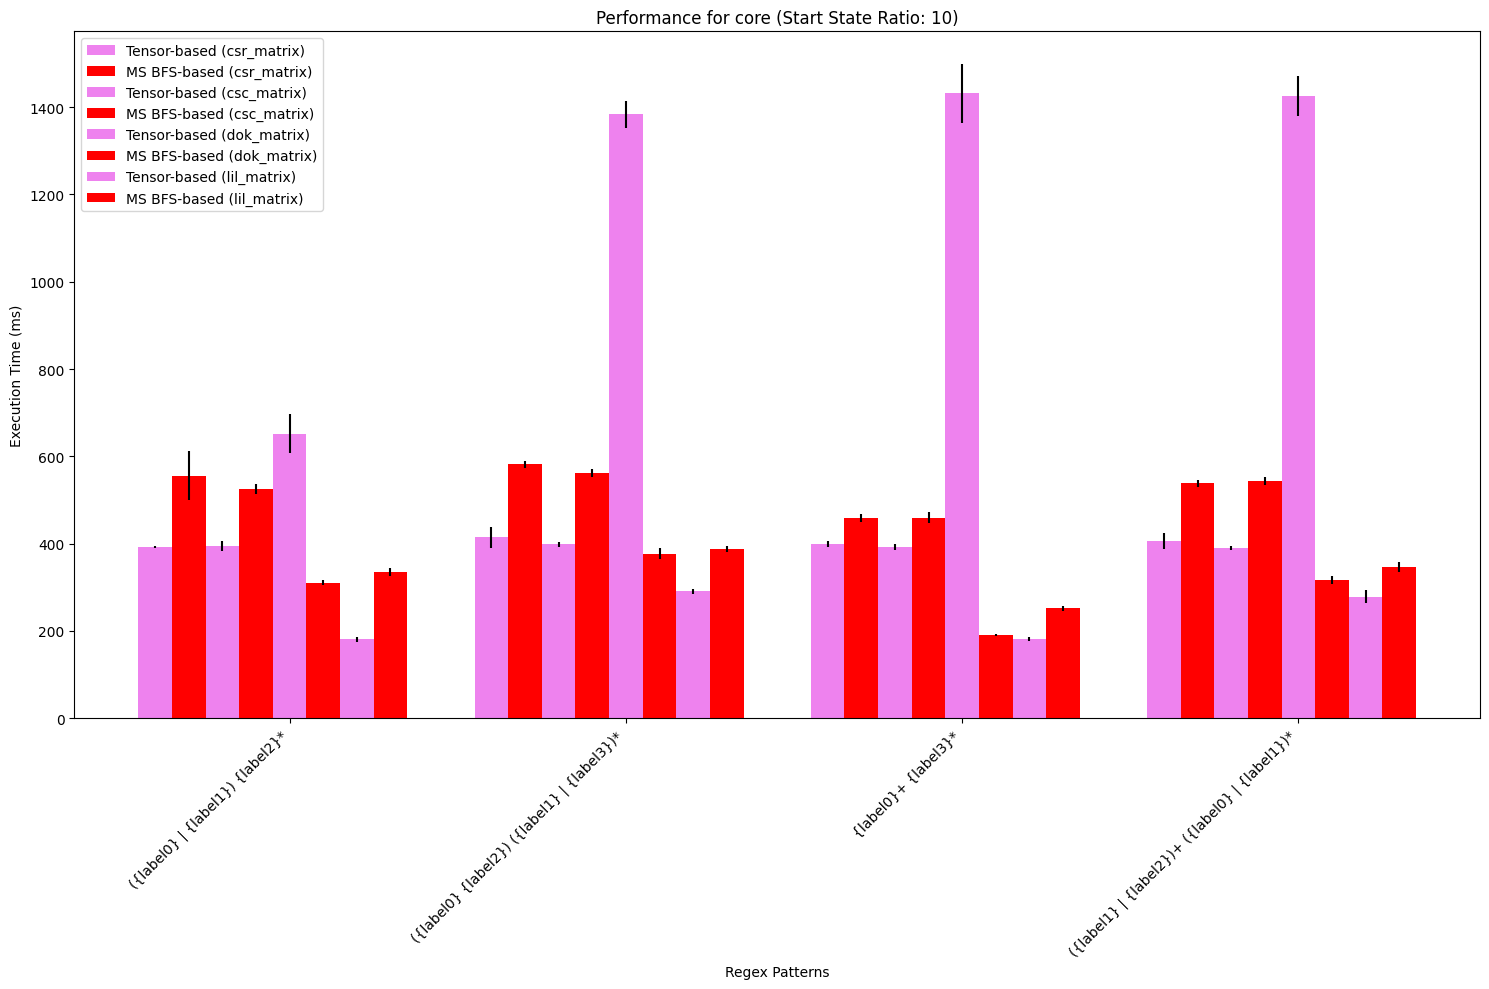

In [75]:
visualize_results("core", 10)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


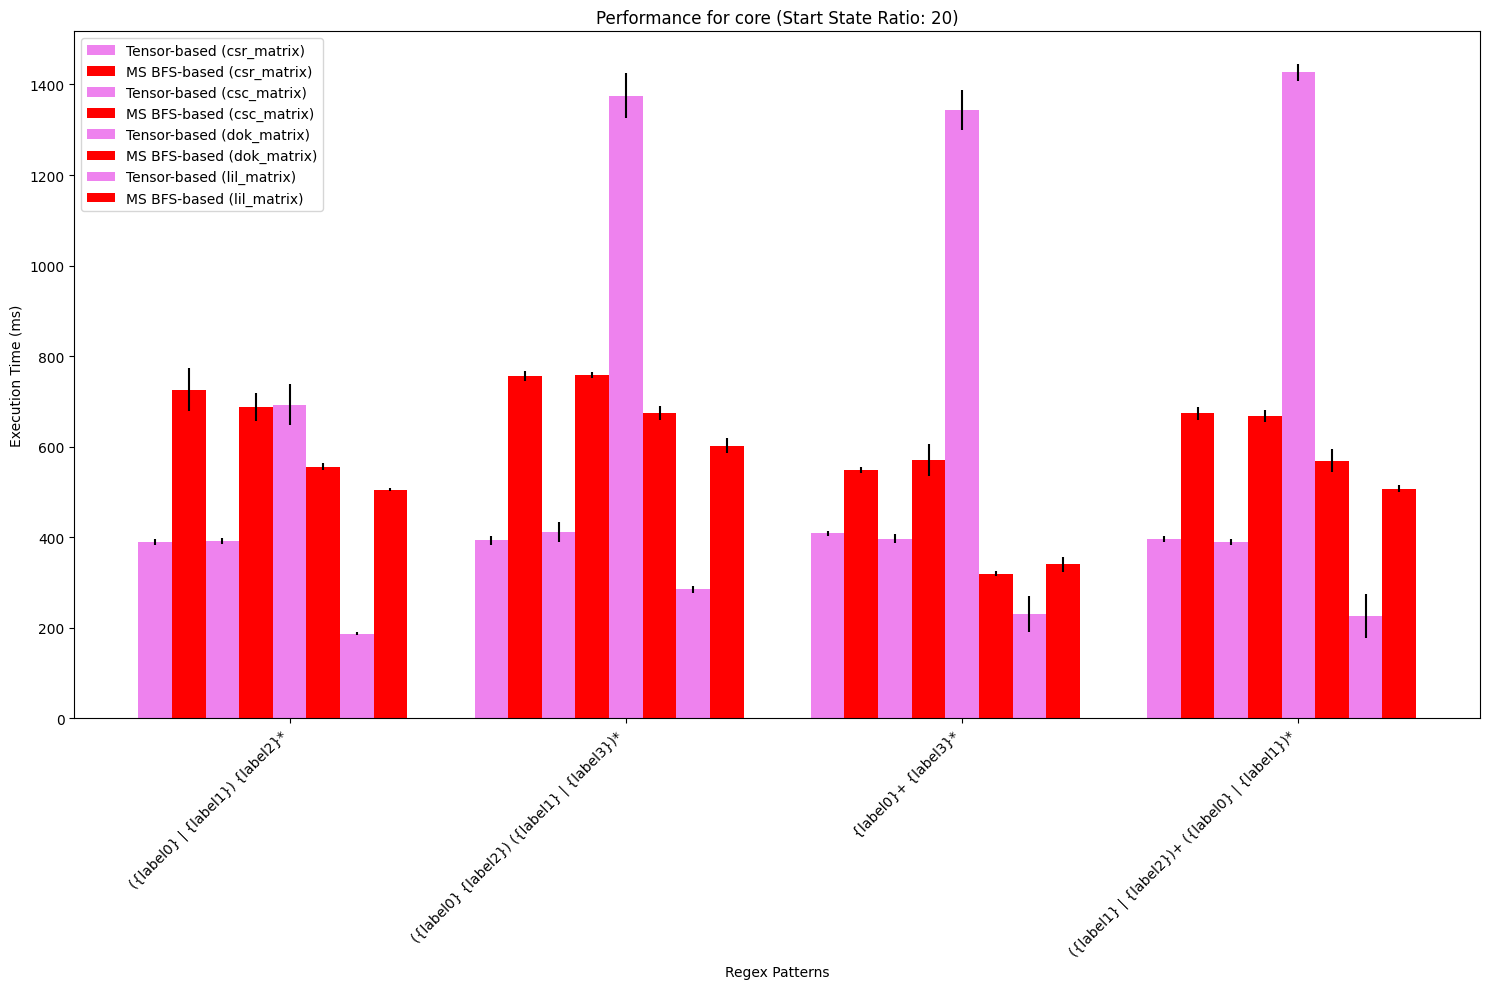

In [76]:
visualize_results("core", 20)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


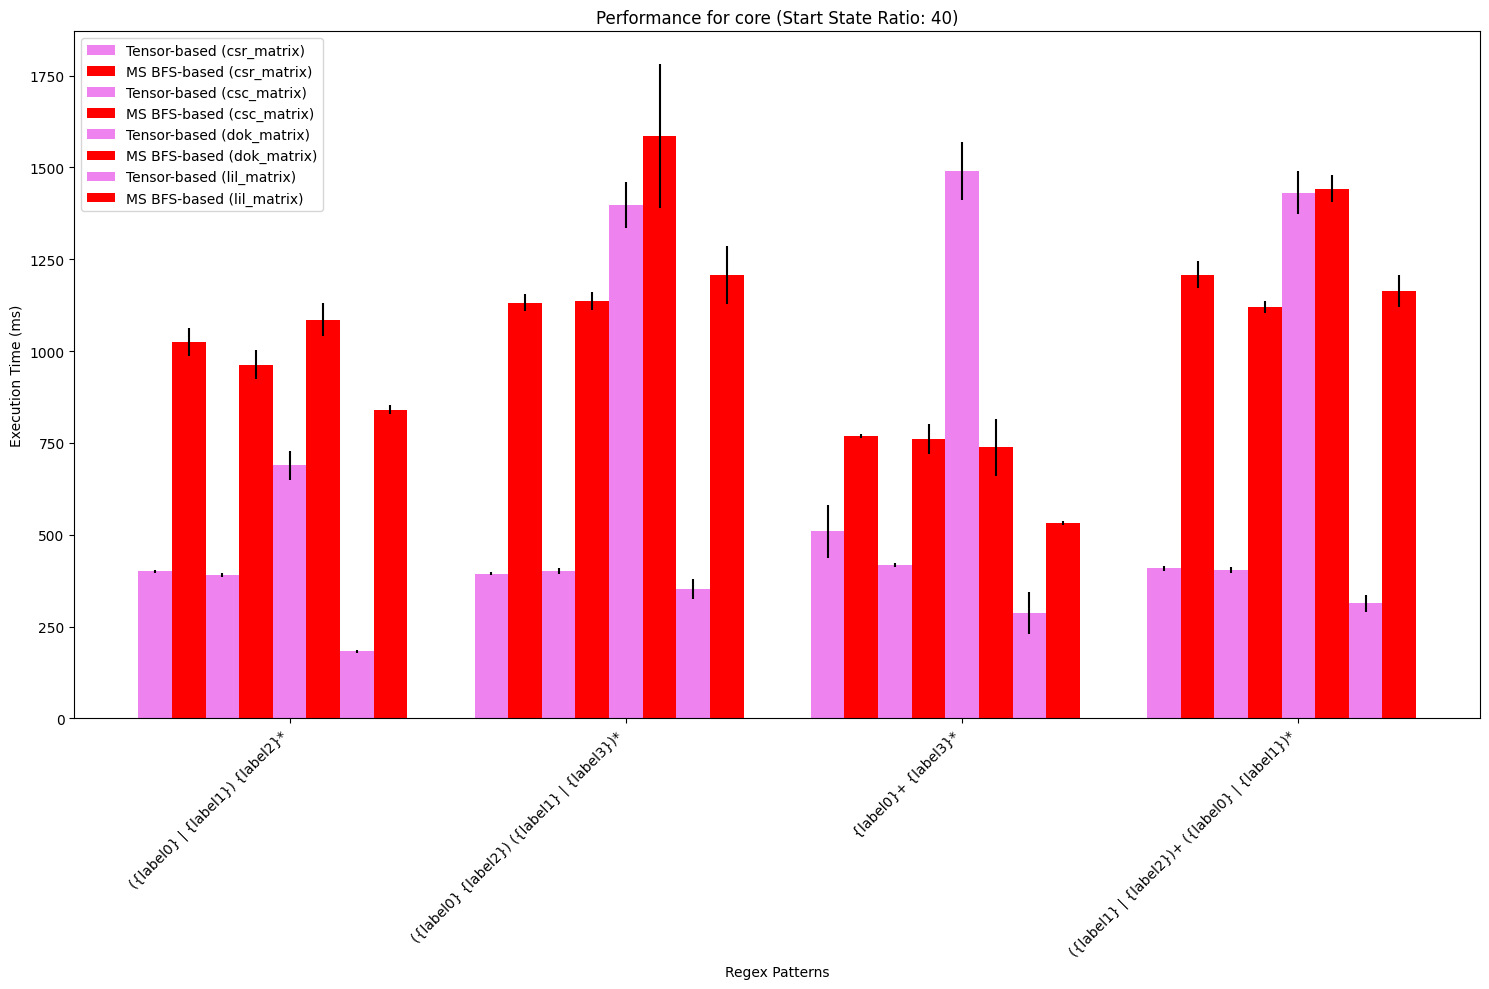

In [77]:
visualize_results("core", 40)

/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/mirida/formal-lang-course/.venv/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


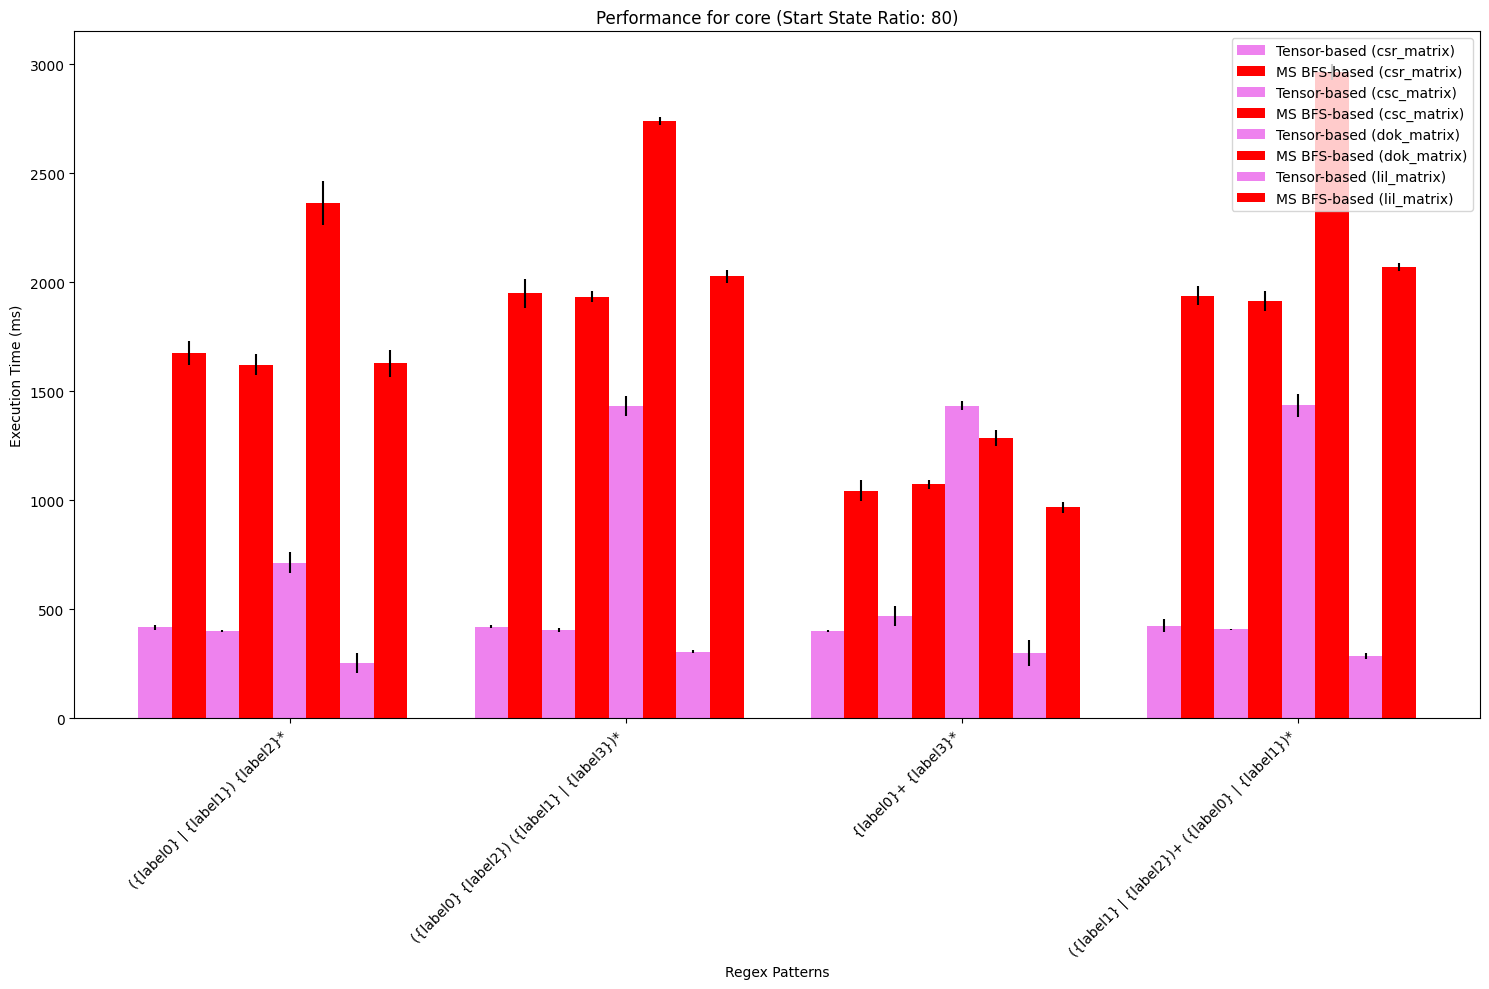

In [78]:
visualize_results("core", 80)

Анализ результатов экспериментов

1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?

    Для ```tensor_based_rpq```: Экспериментальные данные показывают, что с увеличением размера графа различия между форматами матриц становятся менее существенными. Однако наиболее эффективными оказались ```dok_matrix``` и ```lil_matrix```. ```dok_matrix``` демонстрировала высокую производительность на малых графах, в то время как ```lil_matrix``` становилась более предпочтительной при работе с большими графами.

    Для ```ms_bfs_based_rpq```: При анализе производительности различных форматов матриц в зависимости от процента стартовых вершин выявлены следующие закономерности:

    + При низком проценте стартовых вершин ```lil_matrix``` показала наилучшую производительность.
    + С увеличением числа стартовых вершин производительность ```lil_matrix``` снижается, уступая место ```csr_matrix``` и ```csc_matrix```.
    + При высоких процентах стартовых вершин ```csc_matrix``` становится оптимальным выбором, лишь изредка уступая ```csr_matrix```.

    Аргументация выбора форматов:

    + ```lil_matrix``` и ```dok_matrix``` более эффективны при динамических изменениях матриц, что критично для тензорных алгоритмов.
    + ```csr_matrix``` и ```csc_matrix``` оптимальны для обхода графов, что принципиально важно для ms_bfs-алгоритмов.

2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

    Установлено, что производительность ```ms_bfs_based_rpq``` снижается с увеличением числа стартовых вершин. Однако точную границу перехода определить сложно.

    Основные наблюдения:

    + Для малых графов с простыми запросами эффективнее решать задачу полного поиска пар с последующим выбором.
    + Для сложных запросов предпочтительнее использовать ms_bfs-алгоритм с минимально возможным множеством стартовых вершин.
    + Причина падения производительности кроется в механизме multiple source BFS: с ростом числа стартовых вершин front растет линейно, что усложняет эффективность алгоритма.

Рекомендация: При использовании ```ms_bfs_based_rpq``` стремиться к минимизации числа стартовых вершин.

Ключевой вывод: Выбор формата матрицы и алгоритма поиска зависит от конкретной задачи, размера графа и сложности запроса. Необходим индивидуальный подход с учетом специфики решаемой задачи.